# Numerical Optimization

 In this notebook we will review the concepts of:

 - Portfolio optimization through Lagrangage multipier method with Python
 - Mininum variance Portfolio
 - The efficient frontier
 - Portfolios in the efficient frontier (with and without inequalities)
 - Simulating the use of portfolio optimization

All with a portfolio example that includes popular tech assets

In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for optimization problems!
import cvxpy as cp
import scipy.optimize as opt

pd.set_option("display.max_columns", None)

# 1. Download historical financial data


In [14]:
ticker = "TSM"


assets = ["NVDA", "AMD", "TSM", "AVGO", "ASML", "MSFT", "GOOGL", "TLT"]

start_date = "2018-01-01"
end_date = "2026-07-30"

raw = yf.download(
    assets, start=start_date, end=end_date, auto_adjust=True, progress=False
)

X = raw["Close"]
X = X.loc[:"2022-11-30"]

X.tail()
# X.columns

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2022-11-23,76.400002,584.731750,50.414082,97.594604,240.726822,16.478161,88.939964,77.389938
2022-11-25,75.139999,573.101929,50.061707,96.603401,240.639297,16.229780,88.638496,76.851784
2022-11-28,73.190002,564.871033,49.334270,95.205780,235.067917,15.787870,88.888283,74.793602
2022-11-29,73.389999,560.494324,49.256809,94.353348,233.677521,15.600336,87.845985,74.897461
2022-11-30,77.629997,588.866516,52.056953,100.102371,248.077560,16.885481,88.492043,78.343513


# 2. Asset Allocation

In [19]:
monthly_prices = X.resample(
    "ME"
).last()  # we keep only the first and last monthly price
returns = monthly_prices.pct_change().dropna()  # we use aritmetic returns!
returns.head()

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2018-02-28,-0.118632,-0.037298,-0.006330,-0.066231,-0.008415,-0.014848,-0.030414,-0.043258
2018-03-31,-0.170107,0.016224,-0.029850,-0.060494,-0.026661,-0.043016,0.028596,0.009458
2018-04-30,0.082587,-0.042510,-0.026438,-0.017895,0.024652,-0.028888,-0.020881,-0.121343
2018-05-31,0.261948,0.043513,0.098727,0.079935,0.061467,0.122037,0.020044,0.006502
2018-06-30,0.091770,0.006713,-0.024502,0.026536,-0.002327,-0.060629,0.006458,-0.020746


<Axes: xlabel='Ticker', ylabel='Ticker'>

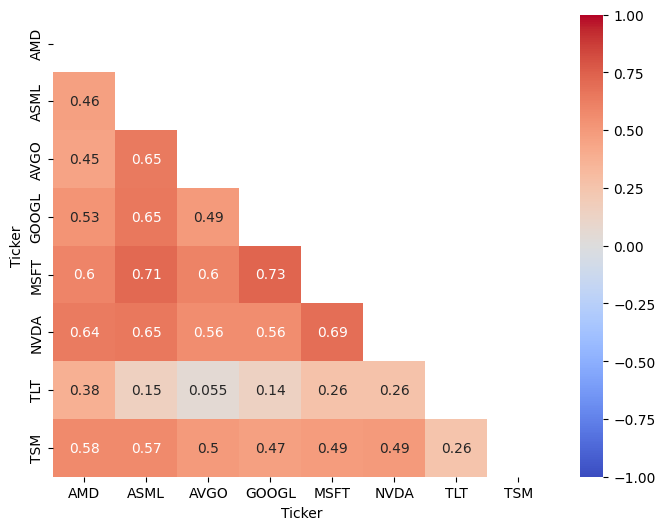

In [27]:
Corr = returns.corr()
mask = np.triu(np.ones_like(Corr, dtype=bool))
plt.figure(figsize=(8, 6))

sns.heatmap(Corr, mask=mask, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [32]:
returns.head()

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2018-02-28,-0.118632,-0.037298,-0.006330,-0.066231,-0.008415,-0.014848,-0.030414,-0.043258
2018-03-31,-0.170107,0.016224,-0.029850,-0.060494,-0.026661,-0.043016,0.028596,0.009458
2018-04-30,0.082587,-0.042510,-0.026438,-0.017895,0.024652,-0.028888,-0.020881,-0.121343
2018-05-31,0.261948,0.043513,0.098727,0.079935,0.061467,0.122037,0.020044,0.006502
2018-06-30,0.091770,0.006713,-0.024502,0.026536,-0.002327,-0.060629,0.006458,-0.020746


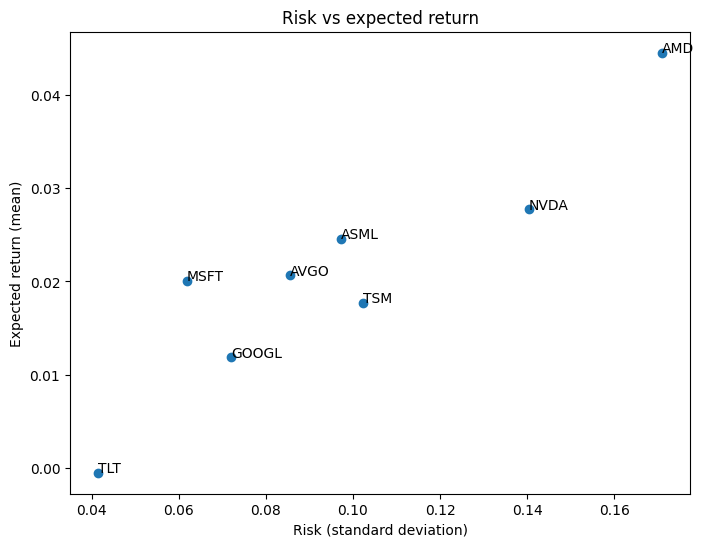

In [31]:
mu = returns.mean()
sigma = returns.std()

plt.figure(figsize=(8, 6))
plt.scatter(sigma, mu)

for asset in returns.columns:
    plt.text(sigma[asset], mu[asset], asset)

plt.xlabel("Risk (standard deviation)")
plt.ylabel("Expected return (mean)")
plt.title("Risk vs expected return")
plt.show()